# Notebook 03 — Data Preprocessing

## Data-Driven Framework for Early Detection of Alzheimer's Disease Using MRI Brain Images

---

### What This Notebook Does
1. Resize all images to 128×128
2. Create stratified train/val/test split (70/15/15)
3. Define data augmentation transforms
4. Handle class imbalance with WeightedRandomSampler
5. Build PyTorch DataLoaders ready for training
6. Save split file lists for reproducibility

### What You Should Check
- Are split ratios approximately 70/15/15?
- Do augmented images look reasonable?
- Are all 4 classes represented in every split?

### Next Notebook
`04_model_training_baseline.ipynb` — Train a custom CNN baseline.

## 1. Setup & Imports

In [1]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.transforms import functional as TF
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid', font_scale=1.1)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_DIR = Path("Data")
PROCESSED_DIR = Path("processed")
PROCESSED_DIR.mkdir(exist_ok=True)

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {idx: name for name, idx in CLASS_TO_IDX.items()}

# ============ Configuration ============
IMG_SIZE = 128          # Resize target (saves VRAM on RTX 4050)
BATCH_SIZE = 32         # Safe for 6GB VRAM
NUM_WORKERS = 0         # MUST be 0 on Windows + Jupyter to avoid hanging
VAL_RATIO = 0.15
TEST_RATIO = 0.15

print(f"Classes: {CLASS_NAMES}")
print(f"Class -> Index mapping: {CLASS_TO_IDX}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

Classes: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
Class -> Index mapping: {'Mild Dementia': 0, 'Moderate Dementia': 1, 'Non Demented': 2, 'Very mild Dementia': 3}
Image size: 128x128
Batch size: 32
Device: cuda


## 2. Collect All Image Paths and Labels

We scan the `Data/` directory and create a master list of `(image_path, label)` pairs.

In [2]:
all_paths = []
all_labels = []

for class_name in CLASS_NAMES:
    class_dir = DATA_DIR / class_name
    for f in sorted(class_dir.iterdir()):
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS:
            all_paths.append(str(f))
            all_labels.append(CLASS_TO_IDX[class_name])

print(f"Total images: {len(all_paths):,}")
print(f"Label distribution: {Counter(all_labels)}")

Total images: 20,960
Label distribution: Counter({3: 13725, 0: 5002, 2: 1745, 1: 488})


## 3. Stratified Train / Validation / Test Split

**Why stratified?** With severe class imbalance, a random split might leave zero Moderate Dementia samples in the validation or test set. Stratified splitting preserves class proportions in each split.

**Split ratios:** 70% train, 15% validation, 15% test

In [3]:
# First split: 70% train, 30% temp (val+test)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=(VAL_RATIO + TEST_RATIO),
    stratify=all_labels,
    random_state=SEED
)

# Second split: split temp 50/50 into val and test (each ~15%)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED
)

print(f"{'Split':<12} {'Count':>8} {'Percentage':>12}")
print("=" * 35)
total = len(all_paths)
for name, paths in [('Train', train_paths), ('Validation', val_paths), ('Test', test_paths)]:
    print(f"{name:<12} {len(paths):>8,} {len(paths)/total*100:>10.1f}%")
print(f"{'TOTAL':<12} {total:>8,} {'100.0%':>12}")

Split           Count   Percentage
Train          14,672       70.0%
Validation      3,144       15.0%
Test            3,144       15.0%
TOTAL          20,960       100.0%


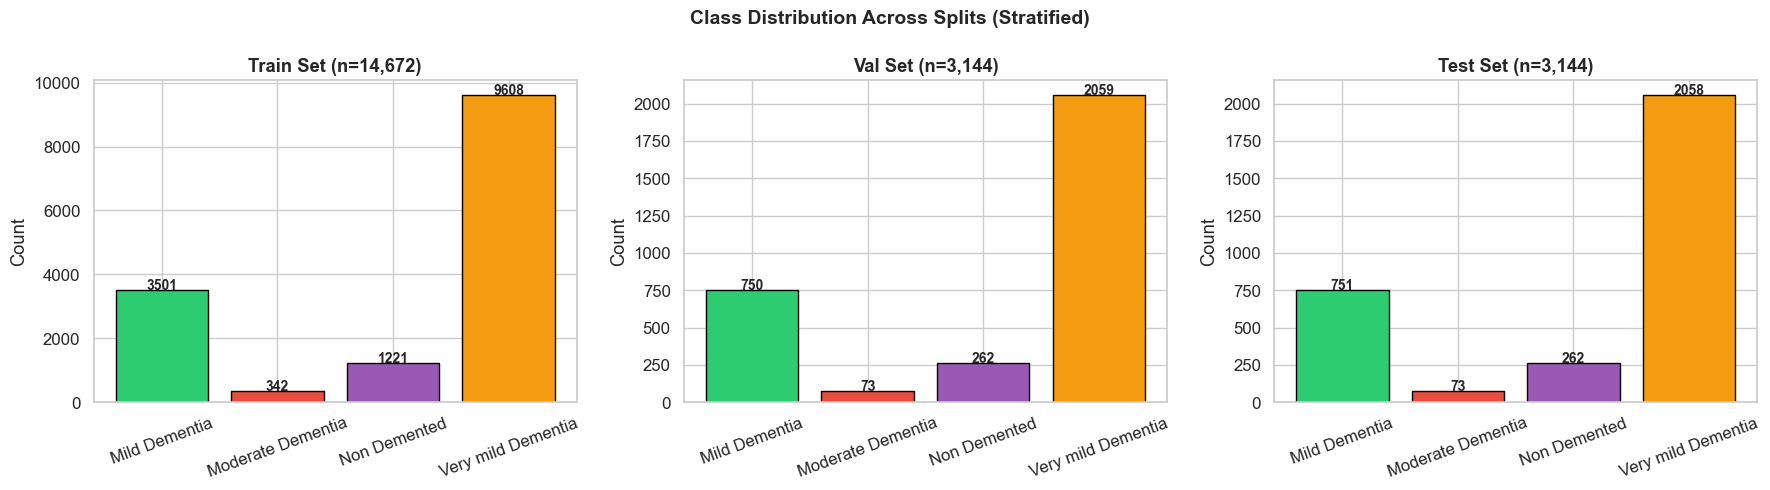

In [4]:
# Verify class distribution is preserved in each split
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Class Distribution Across Splits (Stratified)', fontsize=14, fontweight='bold')

for ax, (name, labels) in zip(axes, [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]):
    counts = Counter(labels)
    classes = [IDX_TO_CLASS[i] for i in sorted(counts.keys())]
    vals = [counts[i] for i in sorted(counts.keys())]
    colors = ['#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
    
    bars = ax.bar(classes, vals, color=colors, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                str(v), ha='center', fontweight='bold', fontsize=10)
    ax.set_title(f'{name} Set (n={sum(vals):,})', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. Save Split File Lists

Saving the splits as CSV files ensures **reproducibility** — we can always reload the exact same split.

In [5]:
for name, paths, labels in [
    ('train', train_paths, train_labels),
    ('val', val_paths, val_labels),
    ('test', test_paths, test_labels)
]:
    df = pd.DataFrame({'path': paths, 'label': labels})
    df['class_name'] = df['label'].map(IDX_TO_CLASS)
    save_path = PROCESSED_DIR / f'{name}_files.csv'
    df.to_csv(save_path, index=False)
    print(f"Saved {name} split ({len(df):,} images) -> {save_path}")

Saved train split (14,672 images) -> processed\train_files.csv
Saved val split (3,144 images) -> processed\val_files.csv
Saved test split (3,144 images) -> processed\test_files.csv


## 5. Define Transforms

### Why These Specific Transforms?

| Transform | Purpose |
|-----------|--------|
| **Resize(128)** | Reduces memory usage — critical for 6GB VRAM |
| **RandomHorizontalFlip** | Brain MRI is roughly symmetrical; flipping is a valid augmentation |
| **RandomRotation(15deg)** | Accounts for slight scan angle variations |
| **RandomAffine** | Simulates slight translations and scaling differences |
| **ColorJitter** | Accounts for scanner brightness/contrast variations |
| **Normalize (ImageNet)** | Required for pretrained model compatibility |

**Important:** Augmentation is applied ONLY to training data. Validation and test use deterministic transforms.

In [6]:
# ============ ImageNet normalization constants ============
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ============ Training transforms (with augmentation) ============
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ============ Validation/Test transforms (NO augmentation) ============
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Training transforms:")
for t in train_transform.transforms:
    print(f"  -> {t}")
print(f"\nValidation/Test transforms:")
for t in val_transform.transforms:
    print(f"  -> {t}")

Training transforms:
  -> Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
  -> RandomHorizontalFlip(p=0.5)
  -> RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
  -> RandomAffine(degrees=[0.0, 0.0], translate=(0.05, 0.05), scale=(0.95, 1.05))
  -> ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
  -> ToTensor()
  -> Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

Validation/Test transforms:
  -> Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
  -> ToTensor()
  -> Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


## 6. Custom PyTorch Dataset

We create a custom `Dataset` class that:
- Loads images from file paths
- Converts to RGB (in case of grayscale files)
- Applies the specified transforms
- Returns `(image_tensor, label)` pairs

In [7]:
class AlzheimerDataset(Dataset):
    """Custom PyTorch Dataset for Alzheimer's MRI classification."""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image and convert to RGB
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label


# Create datasets
train_dataset = AlzheimerDataset(train_paths, train_labels, transform=train_transform)
val_dataset = AlzheimerDataset(val_paths, val_labels, transform=val_transform)
test_dataset = AlzheimerDataset(test_paths, test_labels, transform=val_transform)

print(f"Train dataset: {len(train_dataset):,} images")
print(f"Val dataset:   {len(val_dataset):,} images")
print(f"Test dataset:  {len(test_dataset):,} images")

# Verify a single sample
sample_img, sample_label = train_dataset[0]
print(f"\nSample tensor shape: {sample_img.shape}")
print(f"Sample label: {sample_label} ({IDX_TO_CLASS[sample_label]})")
print(f"Tensor dtype: {sample_img.dtype}")
print(f"Tensor range: [{sample_img.min():.3f}, {sample_img.max():.3f}]")

Train dataset: 14,672 images
Val dataset:   3,144 images
Test dataset:  3,144 images

Sample tensor shape: torch.Size([3, 128, 128])
Sample label: 3 (Very mild Dementia)
Tensor dtype: torch.float32
Tensor range: [-2.118, 1.821]


## 7. Visualize Augmented Images

Let's see what augmented training images look like. We show the same original image with 5 different random augmentations. This confirms our transforms produce realistic variations.

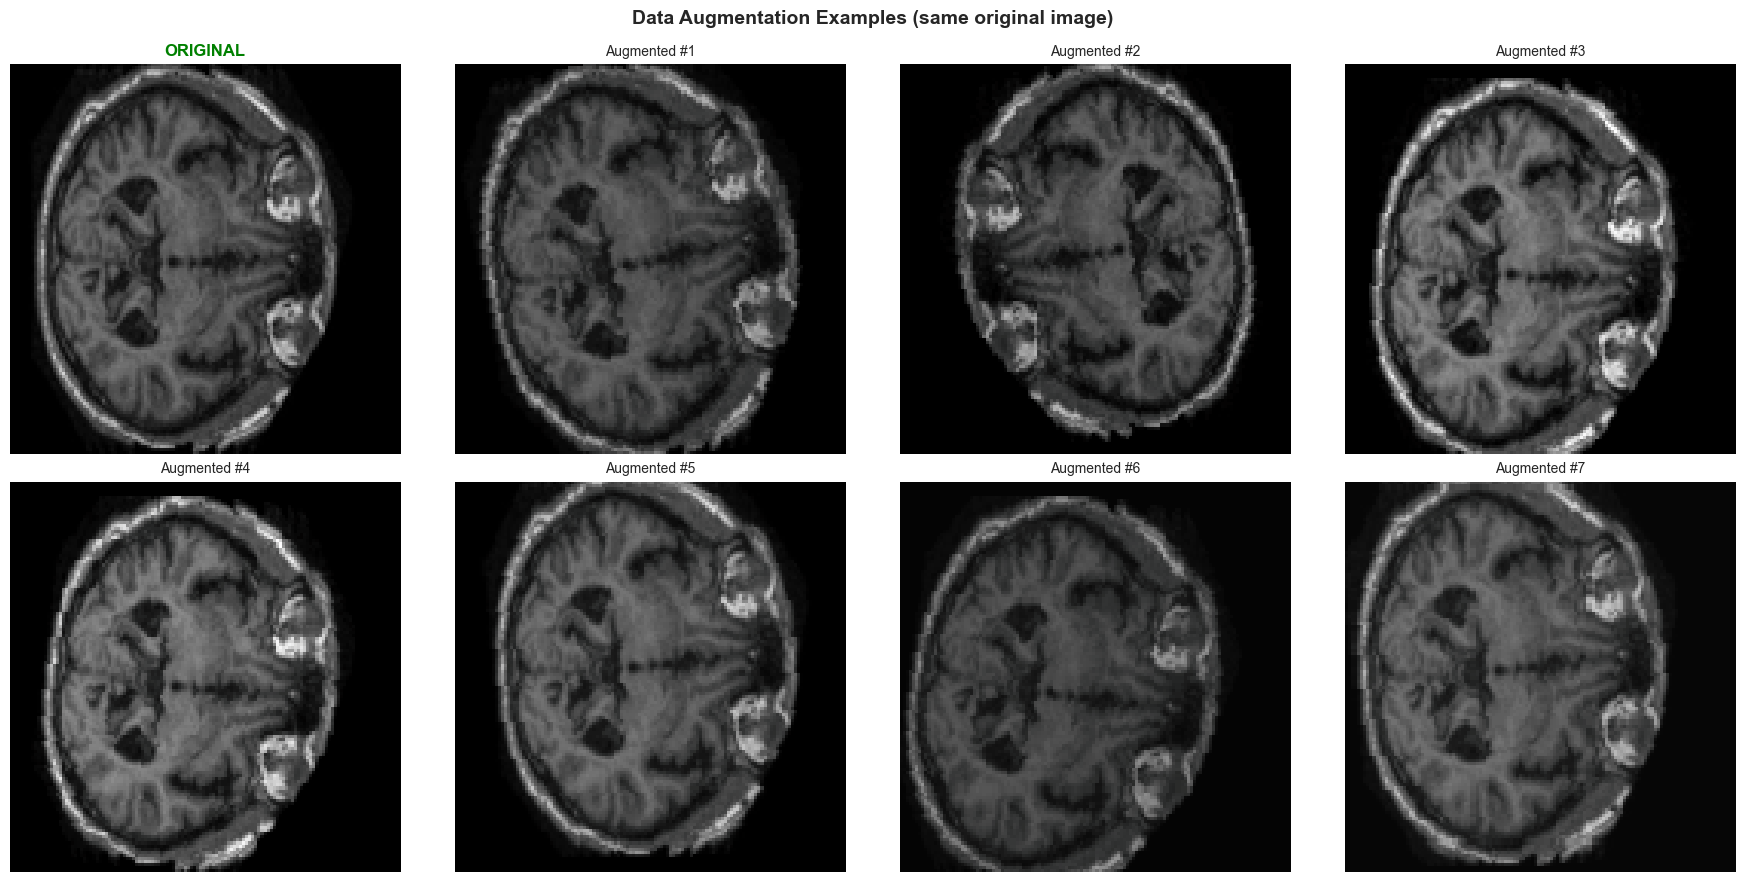

Saved as 'augmentation_examples.png'


In [8]:
def denormalize(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    """Reverse ImageNet normalization for visualization."""
    t = tensor.clone()
    for ch, m, s in zip(t, mean, std):
        ch.mul_(s).add_(m)
    return torch.clamp(t, 0, 1)


# Pick one image and show multiple augmentations
sample_idx = 0
original_path = train_paths[sample_idx]
original_img = Image.open(original_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Data Augmentation Examples (same original image)', fontsize=14, fontweight='bold')

# Show original
axes[0, 0].imshow(original_img)
axes[0, 0].set_title('ORIGINAL', fontweight='bold', color='green', fontsize=12)
axes[0, 0].axis('off')

# Show 7 augmented versions
for i in range(7):
    row = (i + 1) // 4
    col = (i + 1) % 4
    aug_tensor, _ = train_dataset[sample_idx]  # Each call applies random augmentation
    aug_img = denormalize(aug_tensor).permute(1, 2, 0).numpy()
    axes[row, col].imshow(aug_img)
    axes[row, col].set_title(f'Augmented #{i+1}', fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as 'augmentation_examples.png'")

## 8. Handle Class Imbalance — WeightedRandomSampler

### The Problem
Without balancing, the model sees ~100x more "Non Demented" samples than "Moderate Dementia" samples per epoch. It learns to always predict the majority class.

### The Solution: WeightedRandomSampler
- Assign each sample a **sampling weight inversely proportional** to its class frequency
- Minority class samples get **higher weights** -> sampled more often
- Each training batch will contain roughly equal representation of all classes

### Why Not Just Duplicate Minority Samples?
- Static duplication leads to overfitting on the exact same images
- WeightedRandomSampler + augmentation means each time a minority sample is picked, it gets **different random augmentations** -> more diverse training data

In [9]:
# ============ Compute class weights ============
train_label_counts = Counter(train_labels)
total_train = len(train_labels)

# Weight for each CLASS (inverse frequency)
class_weights = {}
for cls_idx in range(len(CLASS_NAMES)):
    count = train_label_counts[cls_idx]
    weight = total_train / (len(CLASS_NAMES) * count)
    class_weights[cls_idx] = weight

print("Class weights (inverse frequency):")
print("=" * 50)
for idx, name in IDX_TO_CLASS.items():
    print(f"  {name:<25} count={train_label_counts[idx]:>5,}  weight={class_weights[idx]:.4f}")

# ============ Create per-sample weights for WeightedRandomSampler ============
sample_weights = [class_weights[label] for label in train_labels]
sample_weights = torch.DoubleTensor(sample_weights)

# Create the sampler
train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True  # Must be True for oversampling minority classes
)

print(f"\nWeightedRandomSampler created with {len(sample_weights):,} sample weights")

# ============ Also compute class weights for CrossEntropyLoss ============
loss_weights = torch.FloatTensor([class_weights[i] for i in range(len(CLASS_NAMES))])
print(f"\nLoss weights tensor: {loss_weights}")
print("(Higher weight = model penalized more for misclassifying that class)")

Class weights (inverse frequency):
  Mild Dementia             count=3,501  weight=1.0477
  Moderate Dementia         count=  342  weight=10.7251
  Non Demented              count=1,221  weight=3.0041
  Very mild Dementia        count=9,608  weight=0.3818

WeightedRandomSampler created with 14,672 sample weights

Loss weights tensor: tensor([ 1.0477, 10.7251,  3.0041,  0.3818])
(Higher weight = model penalized more for misclassifying that class)


## 9. Create DataLoaders

DataLoaders handle **batching, shuffling, and parallel data loading**. Key settings:
- `batch_size=32` — fits in 6GB VRAM
- `num_workers=0` — required on Windows + Jupyter (avoids multiprocessing hang)
- `pin_memory=True` — faster CPU to GPU data transfer
- Train loader uses `WeightedRandomSampler` (no separate `shuffle` needed)
- Val/Test loaders use sequential loading (no shuffling)

In [10]:
# ============ Create DataLoaders ============
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,    # Weighted sampling for class balance
    num_workers=NUM_WORKERS,
    pin_memory=True           # Faster GPU transfer
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,            # No shuffling for evaluation
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train DataLoader: {len(train_loader)} batches x {BATCH_SIZE} = ~{len(train_loader)*BATCH_SIZE:,} samples/epoch")
print(f"Val DataLoader:   {len(val_loader)} batches x {BATCH_SIZE} = ~{len(val_loader)*BATCH_SIZE:,} samples")
print(f"Test DataLoader:  {len(test_loader)} batches x {BATCH_SIZE} = ~{len(test_loader)*BATCH_SIZE:,} samples")

Train DataLoader: 459 batches x 32 = ~14,688 samples/epoch
Val DataLoader:   99 batches x 32 = ~3,168 samples
Test DataLoader:  99 batches x 32 = ~3,168 samples


## 10. Verify Batch Shape & Balanced Sampling

In [11]:
# ============ Verify batch dimensions ============
batch_images, batch_labels = next(iter(train_loader))
print(f"Batch image tensor shape: {batch_images.shape}")   # Expected: [32, 3, 128, 128]
print(f"Batch labels shape:       {batch_labels.shape}")   # Expected: [32]
print(f"Batch image dtype:        {batch_images.dtype}")
print(f"Labels in this batch:     {batch_labels.tolist()}")

assert batch_images.shape == (BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE), "Unexpected batch shape!"
print("\nBatch shape is correct!")

Batch image tensor shape: torch.Size([32, 3, 128, 128])
Batch labels shape:       torch.Size([32])
Batch image dtype:        torch.float32
Labels in this batch:     [1, 1, 0, 3, 3, 3, 3, 2, 3, 0, 1, 2, 1, 3, 0, 2, 2, 1, 1, 0, 2, 0, 1, 0, 3, 0, 1, 2, 3, 2, 2, 3]

Batch shape is correct!


In [12]:
# ============ Verify balanced sampling over multiple batches ============
print("Checking class balance across 50 batches...")
sampled_labels = []
for i, (_, labels) in enumerate(train_loader):
    sampled_labels.extend(labels.tolist())
    if i >= 49:
        break

sampled_counts = Counter(sampled_labels)
total_sampled = sum(sampled_counts.values())

print(f"\nOver {total_sampled:,} sampled images (50 batches):")
for idx in sorted(sampled_counts.keys()):
    pct = sampled_counts[idx] / total_sampled * 100
    bar = '#' * int(pct)
    print(f"  {IDX_TO_CLASS[idx]:<25} {sampled_counts[idx]:>5} ({pct:>5.1f}%) {bar}")

# Check if roughly balanced (each class should be ~25%)
min_pct = min(sampled_counts[i]/total_sampled for i in sampled_counts) * 100
max_pct = max(sampled_counts[i]/total_sampled for i in sampled_counts) * 100

if max_pct - min_pct < 15:
    print("\nWeightedRandomSampler is working! Classes are roughly balanced.")
else:
    print(f"\nImbalance still present (range: {min_pct:.1f}% - {max_pct:.1f}%). This is normal with very small classes.")

Checking class balance across 50 batches...

Over 1,600 sampled images (50 batches):
  Mild Dementia               396 ( 24.8%) ########################
  Moderate Dementia           412 ( 25.8%) #########################
  Non Demented                416 ( 26.0%) ##########################
  Very mild Dementia          376 ( 23.5%) #######################

WeightedRandomSampler is working! Classes are roughly balanced.


## 11. Visualize a Training Batch

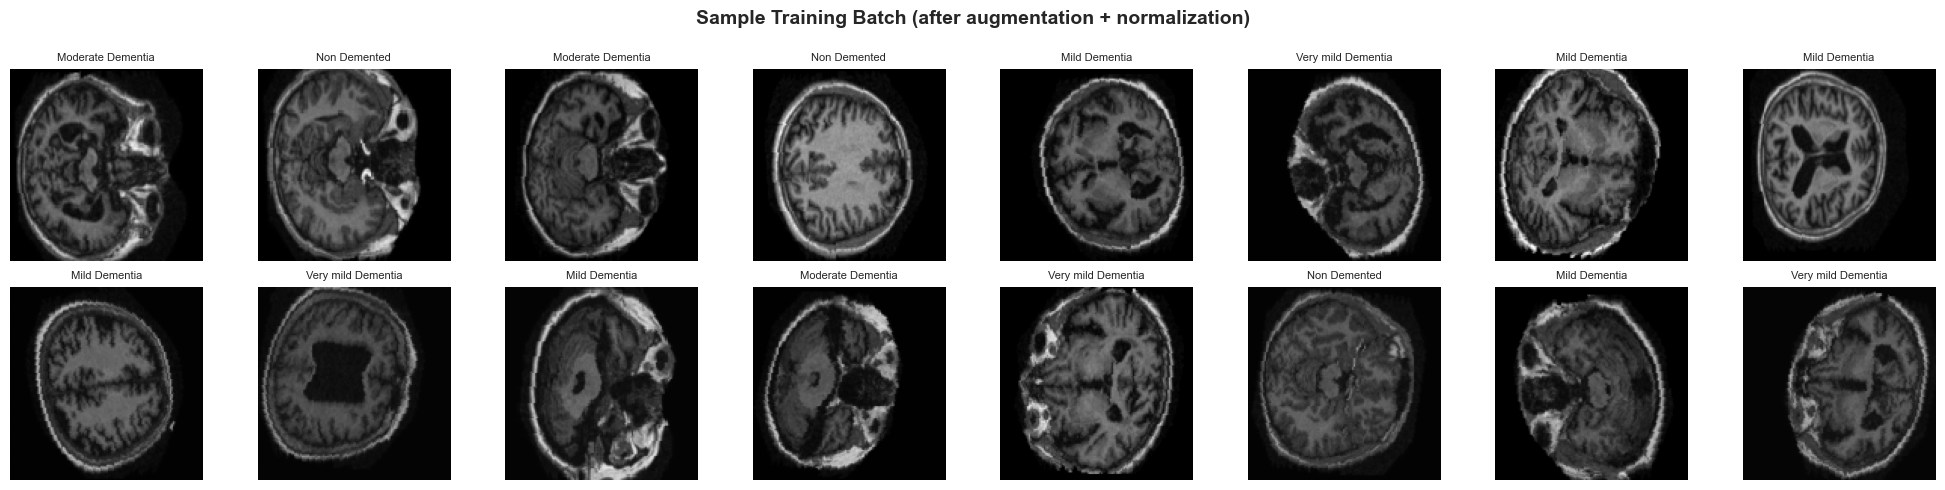

In [13]:
# ============ Show first 16 images from a training batch ============
batch_imgs, batch_lbls = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Sample Training Batch (after augmentation + normalization)', fontsize=14, fontweight='bold')

for i in range(16):
    ax = axes[i // 8, i % 8]
    img = denormalize(batch_imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(IDX_TO_CLASS[batch_lbls[i].item()], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 12. Save Preprocessing Config

Save all preprocessing parameters so Notebooks 04-08 can reload them consistently.

In [14]:
import json

config = {
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'num_workers': NUM_WORKERS,
    'val_ratio': VAL_RATIO,
    'test_ratio': TEST_RATIO,
    'seed': SEED,
    'class_names': CLASS_NAMES,
    'class_to_idx': CLASS_TO_IDX,
    'imagenet_mean': IMAGENET_MEAN,
    'imagenet_std': IMAGENET_STD,
    'num_classes': len(CLASS_NAMES),
    'class_weights': {str(k): round(v, 6) for k, v in class_weights.items()},
    'loss_weights': loss_weights.tolist(),
    'train_size': len(train_paths),
    'val_size': len(val_paths),
    'test_size': len(test_paths)
}

config_path = PROCESSED_DIR / 'preprocessing_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f"Config saved to: {config_path}")
print(f"\nConfig contents:")
for key, val in config.items():
    print(f"  {key}: {val}")

Config saved to: processed\preprocessing_config.json

Config contents:
  img_size: 128
  batch_size: 32
  num_workers: 0
  val_ratio: 0.15
  test_ratio: 0.15
  seed: 42
  class_names: ['Mild Dementia', 'Moderate Dementia', 'Non Demented', 'Very mild Dementia']
  class_to_idx: {'Mild Dementia': 0, 'Moderate Dementia': 1, 'Non Demented': 2, 'Very mild Dementia': 3}
  imagenet_mean: [0.485, 0.456, 0.406]
  imagenet_std: [0.229, 0.224, 0.225]
  num_classes: 4
  class_weights: {'0': 1.047701, '1': 10.725146, '2': 3.004095, '3': 0.381765}
  loss_weights: [1.0477006435394287, 10.725146293640137, 3.0040950775146484, 0.3817651867866516]
  train_size: 14672
  val_size: 3144
  test_size: 3144


## 13. VRAM Estimation

Let's estimate how much GPU memory one batch will use, to make sure we stay within 6GB.

In [15]:
# ============ Estimate VRAM usage per batch ============
# Each image: 3 channels x 128 x 128 pixels x 4 bytes (float32)
bytes_per_image = 3 * IMG_SIZE * IMG_SIZE * 4
bytes_per_batch = bytes_per_image * BATCH_SIZE
mb_per_batch = bytes_per_batch / (1024 ** 2)

print(f"Memory per image:  {bytes_per_image / 1024:.1f} KB")
print(f"Memory per batch:  {mb_per_batch:.1f} MB")
print(f"Batch size:        {BATCH_SIZE}")
print(f"Image size:        {IMG_SIZE}x{IMG_SIZE}")
print(f"\nEstimated VRAM for input data only: {mb_per_batch:.1f} MB")
print(f"Available VRAM: ~6,000 MB")
print(f"Remaining for model + gradients + optimizer: ~{6000 - mb_per_batch:.0f} MB")
print(f"\nThis is well within the 6GB limit.")
print(f"ResNet18 (~45MB) + gradients + optimizer states will fit comfortably.")

Memory per image:  192.0 KB
Memory per batch:  6.0 MB
Batch size:        32
Image size:        128x128

Estimated VRAM for input data only: 6.0 MB
Available VRAM: ~6,000 MB
Remaining for model + gradients + optimizer: ~5994 MB

This is well within the 6GB limit.
ResNet18 (~45MB) + gradients + optimizer states will fit comfortably.


## 14. Summary

### What We Did
1. Collected all image paths and labels
2. Created **stratified** train/val/test split (70/15/15)
3. Defined augmentation transforms (flip, rotate, affine, color jitter)
4. Built custom PyTorch `Dataset` class
5. Created `WeightedRandomSampler` to handle severe class imbalance
6. Built `DataLoader`s with proper batch size for RTX 4050
7. Verified batch shapes and balanced sampling
8. Saved split lists and config for reproducibility

### Files Created
- `processed/train_files.csv` — Training set file paths and labels
- `processed/val_files.csv` — Validation set file paths and labels
- `processed/test_files.csv` — Test set file paths and labels
- `processed/preprocessing_config.json` — All preprocessing parameters

### What to Check
- Splits are approximately 70/15/15
- All 4 classes present in every split
- Augmented images look like valid MRI scans
- WeightedRandomSampler produces roughly balanced batches
- Batch shape is `[32, 3, 128, 128]`

### Next Step
-> **Notebook 04** (`04_model_training_baseline.ipynb`): Train a simple custom CNN as our baseline model.

---
*End of Notebook 03*